# Machine Learning Principles and Concepts: Assignment 2025 - 2026

# Team: Fill in here your full names in alphabetical order

In this assignment you will deal with the traditional problem of Regression, accompanied by several data engineering techniques like the management of categorical features, feature engineering, normalization, dimensionality reduction, and so on.

You will work in pairs according to your preferences. You must provide your solutions inside this notebook. Just place your code below each task (if required, you are allowed to create additional cells). You must also provide comments on the obtained results, and discuss the conclusions as indicated. Of course, you must remove all the example images (i.e. the `Image` commands) that are presented here.

When you complete the assignment:
* Rename the notebook (i.e. the `.ipynb` file) by using **both your surnames in alphabetical order** as the file name.
* Go to File &raquo; Save and Export Notebook as &raquo; HTML (.html). Download the generated HTML file.
* Compress both the `.ipynb` and `.html` files into a single `.zip` file. Ensure that the `.zip` archive includes just these two files and nothing else.
* Rename the `.zip` file and use **both your surnames in alphabetical order** as the file name.
* Finally, upload it to the e-learning platform.

**Important:** **Both** students of a team must upload the **same** `.zip` file into the e-learning platform. We will check only one `.zip` file per team. So, if you upload different versions, then one of them will not be examined. Both students will get the same grade and the same comments into the e-learning platform.

You are free to use any Python library, even if it is not a part of Anaconda. However, in the latter case, please make sure that you mention the appropriate `conda` or `pip` command/s for installing the library. **You are encouraged to handle the dataset by using Pandas dataframes.** Pandas includes numerous tools that will help you solve many of the tasks below with just one or two lines of code.

You are also free to experiment with all algorithm hyper-parameters and all of their supported values.

**Notice 1:** You will experiment with multiple models and techniques. Writing reusable code parts and calling them from inside loops is essential for convenient readability and effective code maintenance. Such approaches will be appreciated.

**Notice 2:** When you run your code, you may get different numbers than the ones presented below. This is normal, as the acquired values largely depend on the applied algortihm parameters. So it is acceptable.

**The deadline for the assignment is 30/01/2026, 22:00 hrs. NO DEADLINE EXTENSION WILL BE GIVEN. Any questions should be addressed to Dr. Leonidas Akritidis, lakritidis@ihu.gr**

## Dataset description

This assignment must be conducted by using the `kc_house_data.csv` dataset. It is a single CSV (Comma Separated Values) file that contains prices for 21613 houses (samples). The CSV file has been uploaded to the e-learning platform along with this notebook.

The dataset contains 21 columns. The `price` column contains the target variable for training our regression models. The rest 20 columns represent other features which can be either numerical, or categorical.


--------------------------------------------------------------- Libraries ---------------------------------------------------------------------------------------------------------------------

The `tqdm` library is used for real time loading bar for the heavy processes with Elapsed < Estimated time, seconds per iteration
We installed it though the prompt of Anacoda
pip install tqdm


## Task 1: Processing the dataset

In this task you will perform some simple pre-processing operations on the given data. There are two sub-tasks in this task. More specifically:

- Drop the columns `id`, `date`, and `zipcode`. The new dataset shape should be 21613 rows by 18 columns.
- The `price` column will be our target variable. After the removal of the 3 aforementioned columns (`id`, `date` and `zipcode`), the `price` column is now first. Move it to the end of the dataset (i.e. the `price` column should be the last one in the dataset).


In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/Dell Latitude/Desktop/MSc/Machine_learning/Assignment 2025-2026/kc_house_data.csv")                                # Import our cvs data file
df = df.drop(columns = ['id', 'date', 'zipcode'])
df['price'] = df.pop('price')                                        # Moving column 'price' to the end of the data frame

df.head()                                                            # df.info()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,price
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650,221900.0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639,538000.0
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062,180000.0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000,604000.0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503,510000.0


## Task 2: Feature engineering

The dataset contains both numerical and categorical features. There are five sub-tasks in this task. More specifically:


### 2.1. Dataset statistics

Report the minimum, maximum, and mean values for each numerical feature.


In [3]:
df_num = df.drop(columns = ['view', 'waterfront', 'condition'])             # Using numeric features only

stats = df_num.describe().loc[['min', 'max', 'mean']]                       # Computing statistics for numeric features

print(stats.T)

                      min           max           mean
bedrooms           0.0000  3.300000e+01       3.370842
bathrooms          0.0000  8.000000e+00       2.114757
sqft_living      290.0000  1.354000e+04    2079.899736
sqft_lot         520.0000  1.651359e+06   15106.967566
floors             1.0000  3.500000e+00       1.494309
grade              1.0000  1.300000e+01       7.656873
sqft_above       290.0000  9.410000e+03    1788.390691
sqft_basement      0.0000  4.820000e+03     291.509045
yr_built        1900.0000  2.015000e+03    1971.005136
yr_renovated       0.0000  2.015000e+03      84.402258
lat               47.1559  4.777760e+01      47.560053
long            -122.5190 -1.213150e+02    -122.213896
sqft_living15    399.0000  6.210000e+03    1986.552492
sqft_lot15       651.0000  8.712000e+05   12768.455652
price          75000.0000  7.700000e+06  540088.141767


### 2.2. How many missing values do we have per column?

Count the number of rows that have missing values per column.

In [4]:
missing_values = df.isnull().sum()

print('Missing values per column:\n',missing_values)


Missing values per column:
 bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
price            0
dtype: int64


### 2.3 How many distinct values do we have per column?

Count the number of distinct values per column.

In [5]:
n = df.nunique()

print("Number of unique values in each column:\n", n)

Number of unique values in each column:
 bedrooms           13
bathrooms          30
sqft_living      1038
sqft_lot         9782
floors              6
waterfront          2
view                5
condition           5
grade              12
sqft_above        946
sqft_basement     306
yr_built          116
yr_renovated       70
lat              5034
long              752
sqft_living15     777
sqft_lot15       8689
price            4028
dtype: int64


### 2.4. Correlation with the target variable (visual)

Study the correlation of each feature with the target variable. More specifically, you must create plots that illustrate the feature values against the target variable. These must be scatter plots similar to the ones that were presented in the notebook about Linear Regression.

Describe the general impression on how the monotony of an input variable is correlated to the monotony of the target variable (e.g. by increasing the value of this feature the price increases/decreases/is unaffected/is affected randomly, and so on).

This is what your figure/s must look like:


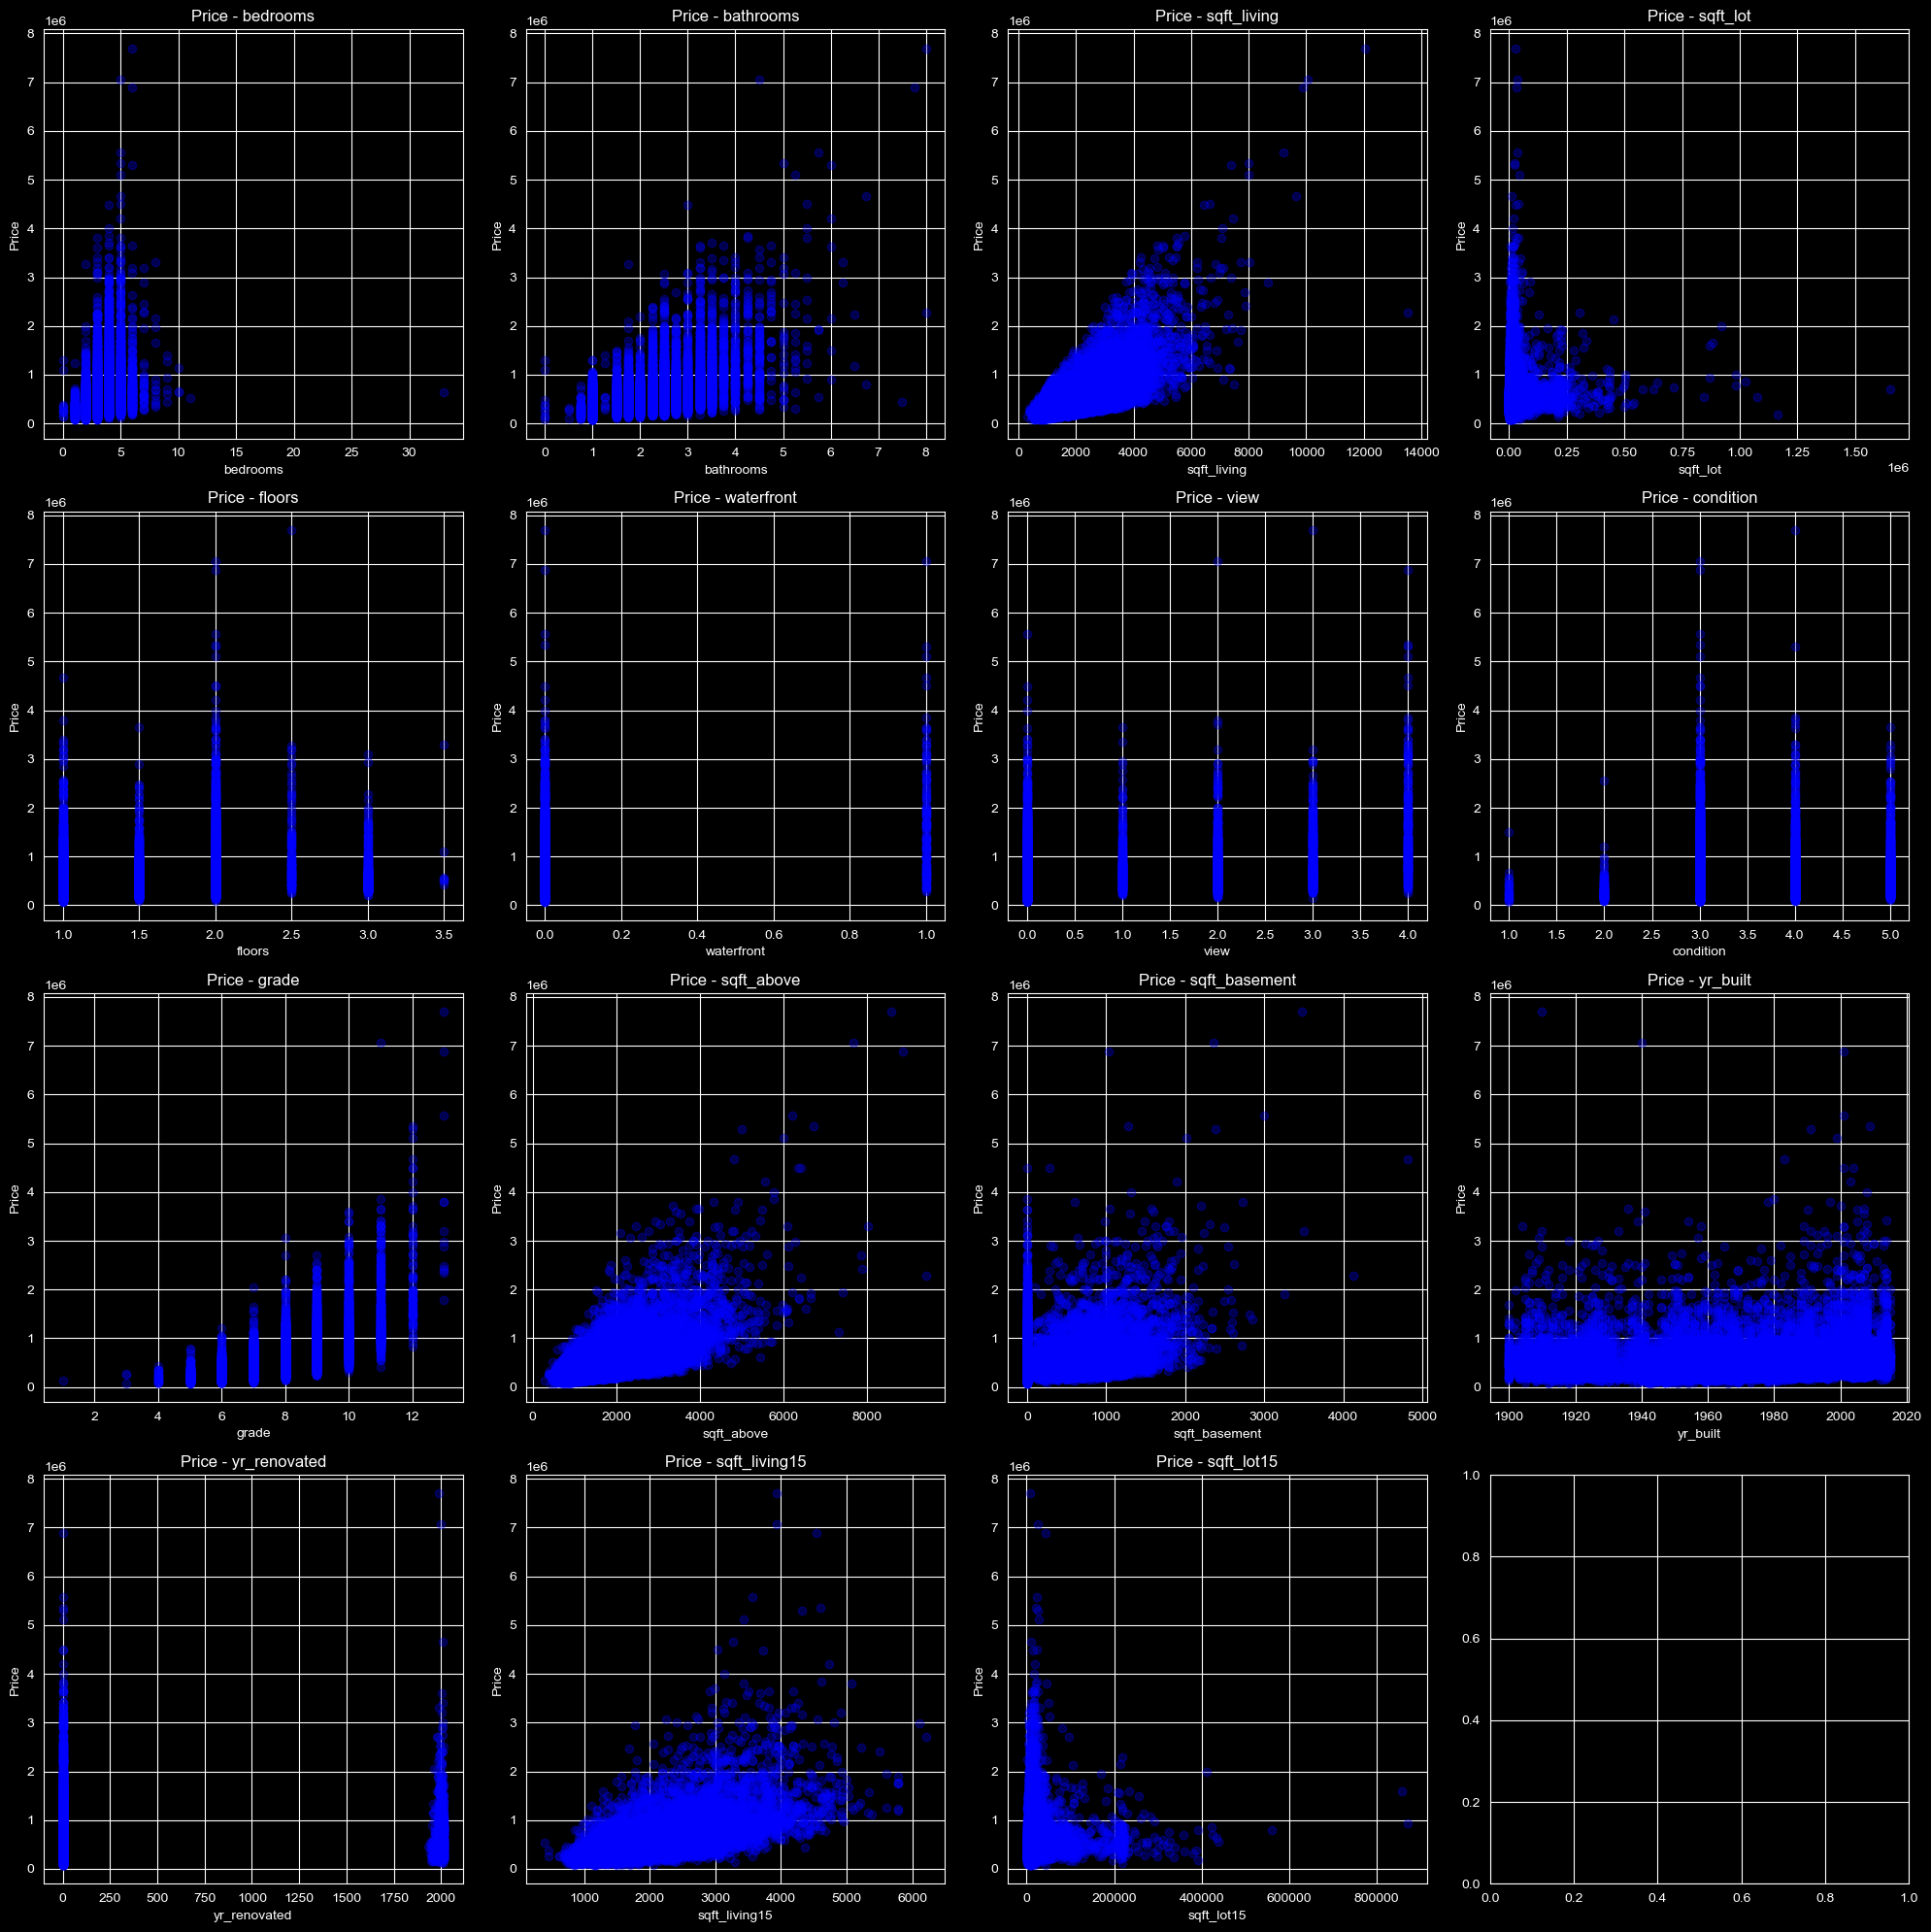

In [6]:
import matplotlib.pyplot as plt

features_visual = []                                                         # Create an array list to add the columns we need to visualize

for col in df.columns:                                                       # For loop only the columns we don't need, and we append inside the array list
    if col !="price" and col !="lat" and col !="long":
        features_visual.append(col)


fig, axes = plt.subplots(4,4, figsize=(20,20))                               # 4x4 grid = 16, but we have 15 columns to visualize below

for i, feature in enumerate(features_visual):                                # Loop by index(i), feature(column)
    ax = axes[i // 4, i % 4]                                                 # Position in the visualize axes, position set as [i//4],[i%4] per loop
    ax.scatter(df[feature],
               df['price'],
               alpha=0.3,
               color='blue')                                                 # Making the scatter comparing Price value - features in the array we made

    ax.set_xlabel(feature)
    ax.set_ylabel("Price")
    ax.set_title(f"Price - {feature}")

plt.tight_layout()
plt.show()

-- **Strong Correlation**
_sqft_living, sqft_above, sqft_living15, grade:_
These features show a clear positive trend: as their values increase, house prices also tend to rise. The relationship is not perfectly linear, which suggests the presence of noise or additional factors influencing price. Nevertheless, the upward pattern is consistent and indicates a strong positive correlation.

-- **Weak or Unclear Correlation**
_bedrooms, bathrooms, sqft_lot, sqft_basement, yr_built, sqft_lot15:_
In these scatter plots, no strong or consistent pattern is visible. Some features show a slight trend, occasionally even a weak negative direction but the points are widely scattered, making the correlation unreliable. These features do not provide a clear predictive relationship with price on their own.

-- **No Meaningful Correlation**
_floors, waterfront, view, condition, yr_renovated:_
These features show no linear correlation with price. Instead of forming a trend, the points appear in clusters or like a step pattern. This suggests that these variables may influence price in a categorical or threshold based way rather than through a continuous linear relationship. As a result, they offer limited predictive power without meaning.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### 2.5 Managing the categorical features

Although all features seem to have numerical values, subsection 2.3 shows that several features receive only distinct values. For example, `view` and `condition` have only 5 distinct values.

In reality, we can either leave these features intact, drop them, or convert them to numerical ones. 
Here you will perform the following actions:

* Treat the following features as categorical ones: `view` and `condition`. Notice that `waterfront` receives binary values, so it is already encoded. Convert `view` and `condition` to numerical ones by applying one-hot-encoding. As mentioned in the class, in one-hot-encoding the first value of each encoded feature is not required. So to reduce dimensionality, remove this first value from each one-hot-encoded feature.
* Again, move the `price` column to the end of the dataset.

  **Hint:** If you are managing the data with Pandas dataframes, use the `get_dummies` method with `drop_first=True`.

After this process, the shape of the dataset must be 21613 rows $\times$ 24 columns.


In [7]:
df_ohe = pd.get_dummies(df,
                        columns=['view', 'condition'],       # Applying One Hot Encoding to 'view' and 'condition' , dropping the first encoded value as requested
                        drop_first = True)                   # Drop True to avoid multicollinearity

                                                             # Moving 'price' again at the end
cols = [col for col in df_ohe.columns if col != 'price']     # Picking all columns except 'price'
cols.append('price')                                         # Adding 'price' again as the last column
df_ohe = df_ohe[cols]                                        # Rebuilding the dataframe
df_ohe


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,grade,sqft_above,sqft_basement,yr_built,...,sqft_lot15,view_1,view_2,view_3,view_4,condition_2,condition_3,condition_4,condition_5,price
0,3,1.00,1180,5650,1.0,0,7,1180,0,1955,...,5650,False,False,False,False,False,True,False,False,221900.0
1,3,2.25,2570,7242,2.0,0,7,2170,400,1951,...,7639,False,False,False,False,False,True,False,False,538000.0
2,2,1.00,770,10000,1.0,0,6,770,0,1933,...,8062,False,False,False,False,False,True,False,False,180000.0
3,4,3.00,1960,5000,1.0,0,7,1050,910,1965,...,5000,False,False,False,False,False,False,False,True,604000.0
4,3,2.00,1680,8080,1.0,0,8,1680,0,1987,...,7503,False,False,False,False,False,True,False,False,510000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,1131,3.0,0,8,1530,0,2009,...,1509,False,False,False,False,False,True,False,False,360000.0
21609,4,2.50,2310,5813,2.0,0,8,2310,0,2014,...,7200,False,False,False,False,False,True,False,False,400000.0
21610,2,0.75,1020,1350,2.0,0,7,1020,0,2009,...,2007,False,False,False,False,False,True,False,False,402101.0
21611,3,2.50,1600,2388,2.0,0,8,1600,0,2004,...,1287,False,False,False,False,False,True,False,False,400000.0


### 2.6 Correlation with the target variables (numerical)

This is an important process, as it indicates the features that are strongly correlated to the target variable. There are several ways of estimating this correlation.

* Compute the Pearson coefficient that quantifies the pairwise correlations of the dataset columns (including the target variable).
* Identify the 8 features that have the strongest correlation with the target variable.
* Create a heatmap of the pairwise feature correlations like the following one.

**Important:** Please remove the sample image `heatmap.png` from your submission.

**Hint:** use the `seaborn` library.

sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
sqft_basement    0.323816
bedrooms         0.308350
view_4           0.307932
Name: price, dtype: float64


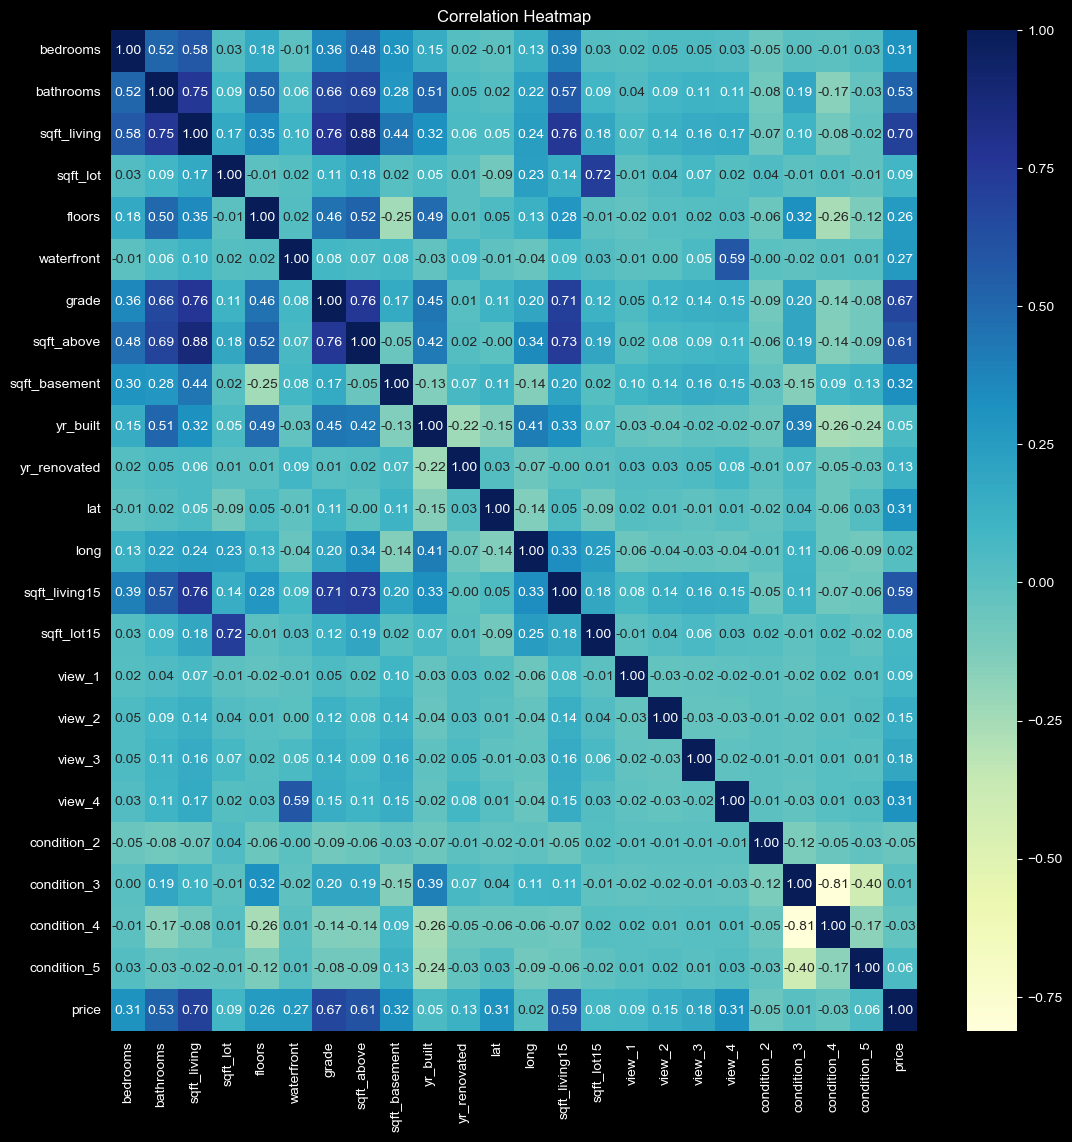

In [8]:
import seaborn as sns

corr_matrix = df_ohe.corr(method='pearson')                       # Creating the correlation matrix showing the correlations among each pair of features

top_8_correlations = (corr_matrix['price']                        # Identifying the 8 features with the strongest correlation to 'price' excluding correlation
                      .drop('price')                              # among price with itself as it will return 1
                      .abs()                                      # We use absolute because negative correlations is as important as positive ones
                      .sort_values(ascending=False).head(8))      # Display 8 first

print(top_8_correlations)

plt.figure(figsize=(13 ,13))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='YlGnBu',
            fmt=".2f")

plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap confirms the conclusions we draw from the scatter plots in the previous exercise (2.4). The features sqft_living, grade, sqft_above, and sqft_living15 show strong positive correlations with price and the trend can be observed visually. Moderate correlations for bathrooms, bedrooms, and sqft_basement also align with our plots. Meanwhile, features such as floors, waterfront, view, condition, and yr_renovated show minimal or no linear correlation, matching the no corresponding or noisy patterns seen earlier. Overall, the heatmap validates our visual interpretations and supports the ranking of predictive features.

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Task 3: Create a model to predict the target variable

This is a typical Regression problem. You will experiment with the following scikit-learn algorithms:

* `LinearRegression`: Ordinary Least Squares Linear Regression.
* `Ridge`: Linear least squares with L2 regularization.
* `Lasso`: Linear Model trained with L1 prior as regularizer (aka the Lasso).
* `DecisionTreeRegressor`: Decision Tree for Regression problems.
* `RandomForestRegressor`: Random Forest for Regression problems.

In addition:
* You will apply 5-fold cross validation.
* You will run the experiments for three different random states: 0, 1, and 42.

Train the models by studying the effect of various hyper-parameters. Create a comparative table of Mean Squared Error, Mean Absolute Error, and R2 score for each algorithm. You must also present the results using bar plots (see the examples below).

**Note 1**: **The table will contain the mean values over all random states and all folds.** In other words, for each model you will first compute the mean value over all 5 folds; three mean values (one for each random state) per moel will derive. Then, you will present the mean of these mean values (over all three random states).

**Note 2:** You will report only the **best-performing results** for each model setting. However, you must mention which settings (i.e. hyperparameters) you tried.

For example: *"We tried Decision Tree Regressor with max_depth=2, 3, 4, 5,... and we got the best results for max_depth=4. The results are..."*


In [9]:
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
import numpy as np_lr 

#----------------------------- Data Preparation --------------------------------------------------------#
X = df_ohe.drop(columns = ['price'])    # Features (everything except the price)
y = df_ohe['price']                     # Target variable
raw_results = []                        # Global variable to append our results from each model

#------------------------------- Linear Regression Model -----------------------------------------------#
def linear_regression_model():

    mse_list = []                                  # Lists to store the average values of the 5 folds
    mae_list = []
    r2_list = []
    random_states = [0, 1, 42]

    scorers = {                                    # Creating a custom scorers dictionary
        'MSE': make_scorer(mean_squared_error),
        'MAE': make_scorer(mean_absolute_error),
        'R2': make_scorer(r2_score)
    }

                                           # Create a pipeline to safely scale within the CV loop
    model_pipeline = Pipeline([            # This automatically fits on the train folds and transforms on the test fold
        ('scaler', StandardScaler()),      # this object implements fit and transform
        ('regressor', LinearRegression())  # this object implements fit and predict
    ])

    for state in random_states:

        kf = KFold(n_splits=5,                            # Setup 5-fold cv
                   shuffle=True,
                   random_state=state)


        cv_results = cross_validate(model_pipeline,       # Run Cross-Validation -> guarantees that every single house (observation)
                                    X,                    # in the dataset is used for testing exactly once per random state
                                    y,
                                    cv=kf,
                                    scoring=scorers)

        avg_mse = np_lr.mean(cv_results['test_MSE'])      # Calculate mean of the 5 folds for this state
        avg_mae = np_lr.mean(cv_results['test_MAE'])
        avg_r2 = np_lr.mean(cv_results['test_R2'])

        mse_list.append(avg_mse)                          # Filling the lists with the values each random state produced (3 items per list)
        mae_list.append(avg_mae)
        r2_list.append(avg_r2)


        print('State:', state, '\nMAE:', avg_mae, '\nR2:', avg_r2)    # Progress for each random state


    grand_mse = np_lr.mean(mse_list)                      # Calculate the means for all k-folds & random states
    grand_mae = np_lr.mean(mae_list)
    grand_r2 = np_lr.mean(r2_list)


    print("-" * 30)                                       # Print Final Summary
    print("FINAL LINEAR REGRESSION RESULTS:")
    print('Mean Squared Error:' ,grand_mse)
    print('Mean Absolute Error:', grand_mae)
    print('R^2 Score', grand_r2)


    raw_results.append(("Linear Regression",              # Append the results to our global list
                        grand_mse,
                        grand_mae,
                        grand_r2))

    return "Linear Regression", grand_mse, grand_mae, grand_r2


linear_regression_model()                                 # Run the model

State: 0 
MAE: 126317.05178192581 
R2: 0.6942753926021668
State: 1 
MAE: 126235.11225536131 
R2: 0.6959665499810226
State: 42 
MAE: 126279.3646198073 
R2: 0.6955252753494031
------------------------------
FINAL LINEAR REGRESSION RESULTS:
Mean Squared Error: 41157226814.24767
Mean Absolute Error: 126277.17621903146
R^2 Score 0.6952557393108642


('Linear Regression',
 41157226814.24767,
 126277.17621903146,
 0.6952557393108642)

Although the MSE appears large due to the squaring of high value residuals, the R2 score of 0.695 indicates the model captures nearly 70% of the variance in the data. The MAE of $126k represents an average error of roughly 23% relative to the mean house price, which is an expected baseline performance for a simple linear model


In [10]:
from sklearn.linear_model import Lasso
import numpy as np
from tqdm import tqdm

#------------------------------- Lasso Regression-L1  -----------------------------------------------#
def lasso_regression_l1():

    alphas_to_try = [1, 10, 100, 500]                    # Different hyperparameters to try


    best_alpha = None                                    # Save here the best alpha parameter
    best_r2 = -float('inf')                              # Start with a very low score to compare with
    best_mse = []                                        # To store the MSE of the winner alpha
    best_mae = []                                        # To store the MAE of the winner alpha

    random_states = [0, 1, 42]

    scorers = {                                          # Creating a custom scorers dictionary
        'MSE': make_scorer(mean_squared_error),
        'MAE': make_scorer(mean_absolute_error),
        'R2': make_scorer(r2_score)
    }
    print('Alpha', '|', 'R2 Score' ,'|', 'MAE')
    print("-" * 45)

    for alpha in alphas_to_try:

        current_alpha_mse = []                            # Keep current MSE,MAE,R2  scores in lists
        current_alpha_mae = []
        current_alpha_r2 = []

        model_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Lasso(alpha=alpha,              # Relaxing the tolerance to the first decimal because the algorithm
                                max_iter=10000,           # couldn't converge even with 10000 iterations for small alpha
                                tol=0.1))


        ])

        for state in tqdm(random_states,                  # Validate across all 3 random states
                          desc=f"Testing Alpha {alpha}",  # We set loading bar to see the progress of heavy procedures
                          leave=False,
                          colour='green'):

            kf = KFold(n_splits=5,
                       shuffle=True,
                       random_state=state)


            cv_results = cross_validate(model_pipeline,    # Run Cross-Validation -> guarantees that every single house (observation) in the dataset
                                        X,                 # is used for testing exactly once per random state
                                        y,
                                        cv=kf,
                                        scoring=scorers)


            current_alpha_mse.append(np_lr.mean(cv_results['test_MSE']))    # Filling the lists with the mean values of the 5 folds for this particular alpha and random state
            current_alpha_mae.append(np_lr.mean(cv_results['test_MAE']))
            current_alpha_r2.append(np_lr.mean(cv_results['test_R2']))


        grand_mse = np_lr.mean(current_alpha_mse)                           # Calculate Grand Means across all 3 random states for this particular a
        grand_mae = np_lr.mean(current_alpha_mae)
        grand_r2 = np_lr.mean(current_alpha_r2)

        print(alpha, '|', grand_r2, '|', grand_mae)

                                                                            # Compare metrics for each alpha and keep the best one
        if grand_r2 > best_r2:                                              # Choosing R2 to be the criterion of the better alpha
            best_r2 = grand_r2
            best_alpha = alpha
            best_mse = grand_mse
            best_mae = grand_mae

    print("-" * 45)
    print("FINAL LASSO REGRESSION RESULTS:")                                # Print Final Summary
    print('Mean Squared Error:' ,best_mse)
    print('Mean Absolute Error:', best_mae)
    print('R2 Score:', best_r2)

    raw_results.append(("Lasso Regression",                                 # Append the results to our global list
                        best_alpha,
                        best_mse,
                        best_mae,
                        best_r2))

    return "Lasso Regression",best_alpha, best_mse, best_mae, best_r2

lasso_regression_l1()                                                       # Run the model

Alpha | R2 Score | MAE
---------------------------------------------


1 | 0.6952648741046241 | 126263.7389925423


10 | 0.6952922682770705 | 126259.51783830335


100 | 0.6953359959590432 | 126282.16714824368


                                                                3.14it/s]

500 | 0.6951738846722364 | 126408.59145347244
---------------------------------------------
FINAL LASSO REGRESSION RESULTS:
Mean Squared Error: 41144733328.27007
Mean Absolute Error: 126282.16714824368
R2 Score: 0.6953359959590432


('Lasso Regression',
 100,
 41144733328.27007,
 126282.16714824368,
 0.6953359959590432)

We found that alpha=100 provided the best performance, though the improvement over the baseline Linear Regression was negligible (~0.0001 R² increase).

In [11]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_validate, KFold
import numpy as np_lr
import numpy as np

#------------------------------- Ridge Regression-L2  -----------------------------------------------#
def ridge_regression_l2():

    alphas_to_try = [1, 10, 100, 500]                     # Different hyperparameters to try


    best_alpha = None                                     # Variables to track the best alpha hyperparameter
    best_r2 = -float('inf')                               # Start with a very low score to compare with
    best_mse = []                                         # To store the MSE of the winner alpha
    best_mae = []                                         # To store the MAE of the winner alpha

    random_states = [0, 1, 42]

    scorers = {                                           # Creating a custom scorers dictionary
        'MSE': make_scorer(mean_squared_error),
        'MAE': make_scorer(mean_absolute_error),
        'R2': make_scorer(r2_score)
    }
    print('Alpha', '|', 'R2 Score' ,'|', 'MAE')
    print("-" * 45)

    for alpha in alphas_to_try:

        current_alpha_mse = []                            # Keep current MSE,MAE,R2  scores in lists
        current_alpha_mae = []
        current_alpha_r2 = []

        model_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('regressor', Ridge(alpha=alpha,
                                max_iter=10000,
                                tol=0.1))                 # Tuning the lambda (λ) strength to prevent overfitting
        ])

        for state in tqdm(random_states,                  # Validate across all 3 random states
                          desc=f"Ridge "                  # Set loading bar
                               f"(λ={alpha})",
                          leave=False,
                          colour='green'):

            kf = KFold(n_splits=5,
                       shuffle=True,
                       random_state=state)


            cv_results = cross_validate(model_pipeline,   # Run Cross-Validation -> guarantees that every single house (observation)
                                        X,                # in the dataset is used for testing exactly once per random state
                                        y,
                                        cv=kf,
                                        scoring=scorers)


            current_alpha_mse.append(np_lr.mean(cv_results['test_MSE']))   # Filling the lists with the mean values of the 5 folds for this particular alpha and random state
            current_alpha_mae.append(np_lr.mean(cv_results['test_MAE']))
            current_alpha_r2.append(np_lr.mean(cv_results['test_R2']))


        grand_mse = np_lr.mean(current_alpha_mse)                          #  # Calculate Grand Means across all 3 random states for this particular a
        grand_mae = np_lr.mean(current_alpha_mae)
        grand_r2 = np_lr.mean(current_alpha_r2)

        print(alpha, '|', grand_r2, '|', grand_mae)

                                                                           # Compare metrics for each alpha and keep the best one
        if grand_r2 > best_r2:                                             # Choosing R2 to be the criterion of the better alpha
            best_r2 = grand_r2
            best_alpha = alpha
            best_mse = grand_mse
            best_mae = grand_mae

    print("-" * 45)                                                        # Print Final Summary
    print("FINAL RIDGE REGRESSION RESULTS:")
    print('Mean Squared Error:' ,best_mse)
    print('Mean Absolute Error:', best_mae)
    print('R2 Score:', best_r2)


    raw_results.append(("Ridge Regression",                                # Append the results to our global list
                        best_alpha,
                        best_mse,
                        best_mae,
                        best_r2))

    return "Ridge Regression",best_alpha, best_mse, best_mae, best_r2


ridge_regression_l2()                                                      # Run the model

Alpha | R2 Score | MAE
---------------------------------------------


1 | 0.6952654435821378 | 126261.80932480609


10 | 0.6952879691913928 | 126241.83295023418


100 | 0.695372106862941 | 126066.55036117138


                                                            3.38it/s]

500 | 0.6952891729517171 | 125429.24929066958
---------------------------------------------
FINAL RIDGE REGRESSION RESULTS:
Mean Squared Error: 41144835360.76386
Mean Absolute Error: 126066.55036117138
R2 Score: 0.695372106862941


('Ridge Regression',
 100,
 41144835360.76386,
 126066.55036117138,
 0.695372106862941)

In [12]:
from sklearn import tree

#------------------------------- Decision Tree Regression -----------------------------------------------#
def decision_tree_regression():

    depths_to_try = [None, 5, 10, 15, 20]                  # Different hyperparameters to try (depths of the tree)


    best_depth = None                                      # Variables to track the best depth
    best_r2 = -float('inf')                                # Start with a very low score to compare with
    best_mse = []                                          # To store the MSE of the winner alpha
    best_mae = []                                          # To store the MAE of the winner alpha

    random_states = [0, 1, 42]

    scorers = {                                            # Creating a custom scorers dictionary
        'MSE': make_scorer(mean_squared_error),
        'MAE': make_scorer(mean_absolute_error),
        'R2': make_scorer(r2_score)
    }
    print('Depth', '|', 'R2 Score' ,'|', 'MAE')
    print("-" * 45)

    for depth in depths_to_try:

        current_depth_mse = []                              # Reset lists for this specific depth
        current_depth_mae = []
        current_depth_r2 = []


        model_pipeline = Pipeline([('regressor',            # No need to standardize data for decision tree regressor
                                    tree.
                                    DecisionTreeRegressor(max_depth=depth,
                                                          random_state=42))])


        for state in random_states:                         # Validate across all 3 random states

            kf = KFold(n_splits=5,
                       shuffle=True,
                       random_state=state)


            cv_results = cross_validate(model_pipeline,      # Run Cross-Validation -> guarantees that every single house (observation)
                                        X,                   # in the dataset is used for testing exactly once per random state
                                        y,
                                        cv=kf,
                                        scoring=scorers)


            current_depth_mse.append(np.mean(cv_results['test_MSE']))     # Filling the lists with the mean values of the 5 folds for this particular depth and random state
            current_depth_mae.append(np.mean(cv_results['test_MAE']))
            current_depth_r2.append(np.mean(cv_results['test_R2']))


        grand_mse = np.mean(current_depth_mse)                            # Calculate Grand Means across all 3 random states for this particular depth
        grand_mae = np.mean(current_depth_mae)
        grand_r2 = np.mean(current_depth_r2)

        print(depth, '|', grand_r2, '|', grand_mae)

                                                                          # Compare metrics for each alpha and keep the best one
        if grand_r2 > best_r2:                                            # Choosing R2 to be the criterion of the better alpha
            best_r2 = grand_r2
            best_depth = depth
            best_mse = grand_mse
            best_mae = grand_mae


    print("-" * 45)                                                      # Print final Summary
    print("FINAL TREE REGRESSION RESULTS:")
    print('Mean Squared Error:' ,best_mse)
    print('Mean Absolute Error:', best_mae)
    print('R2 Score:', best_r2)

    raw_results.append(("Decision Tree Regression",                      # Append the results to our global list
                        best_depth,
                        best_mse,
                        best_mae,
                        best_r2))

    return "Decision Tree Regression",best_depth, best_mse, best_mae, best_r2

decision_tree_regression()                                               # Run the model

Depth | R2 Score | MAE
---------------------------------------------
None | 0.7491847998088309 | 99486.37879955008
5 | 0.6980454943630209 | 114109.8434374787
10 | 0.7866455811297565 | 90439.20847843314
15 | 0.7728862330151863 | 92309.19805609093
20 | 0.7472329279055859 | 98438.52301260857
---------------------------------------------
FINAL TREE REGRESSION RESULTS:
Mean Squared Error: 28822890057.70738
Mean Absolute Error: 90439.20847843314
R2 Score: 0.7866455811297565


('Decision Tree Regression',
 10,
 28822890057.70738,
 90439.20847843314,
 0.7866455811297565)

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from itertools import product

#------------------------------- Random Forest Regression -----------------------------------------------#
def random_forest_regression():

                                           # Different hyperparameters to try [4 hours estimated hours fail and trail to find the best]
    #depths_to_try = [None, 5, 10, 15]     # maximum depth of each tree
    #estimators_to_try = [50, 100]         # we compare 50 vs 100 trees
    #min_split = 2                         # testing for potential overfitting

                                           # After trying the above hyperparameters (but with min_samples_split = 2)
    depths_to_try = [None]                 # we found the best combination
    estimators_to_try = [100]
    min_split = 10


    best_depth = None                      # Variables to track the best depth and estimators combination
    best_estimator = None
    best_r2 = -float('inf')                # Start with a very low score to compare with
    best_mse = []                          # To store the MSE of the winner alpha
    best_mae = []                          # To store the MAE of the winner alpha

    random_states = [0, 1, 42]


    scorers = {                                                # Creating a custom scorers dictionary
        'MSE': make_scorer(mean_squared_error),
        'MAE': make_scorer(mean_absolute_error),
        'R2': make_scorer(r2_score)
    }
    print('Trees','|', 'Depth', '|', 'R2 Score' ,'|', 'MAE')
    print("-" * 55)


    tasks = list(product(depths_to_try, estimators_to_try))    # Combine depth and estimator into a list of tasks for the loading bar


    for depth, estimator in tqdm(tasks,                        # Setting loading bar to see the progress
                                 desc="Hyperparameter Tuning",
                                 colour='green'):


            current_combo_mse = []                             # Temporary lists for this specific depth,trees combination
            current_combo_mae = []
            current_combo_r2 = []


            model_pipeline = Pipeline([('regressor',           # min_samples_list sets the minimum samples that the deeper node can have
                                        RandomForestRegressor(n_estimators=estimator,
                                                              max_depth = depth,
                                                              min_samples_split= min_split,
                                                              random_state = 42))])


            for state in tqdm(random_states,                   # Validate across all 3 random states
                              desc="Cross-Validating States",  # we set also here loading bar
                              leave=False,
                              colour='green'):

                kf = KFold(n_splits=5,
                           shuffle=True,
                           random_state=state)


                cv_results = cross_validate(model_pipeline,    # Run Cross-Validation -> guarantees that every single house (observation)
                                            X,                 # in the dataset is used for testing exactly once per random state
                                            y,
                                            cv=kf,
                                            scoring=scorers)


                current_combo_mse.append(np.mean(cv_results['test_MSE']))  # Filling the lists with the mean values of the 5 folds for this particular depth and random state
                current_combo_mae.append(np.mean(cv_results['test_MAE']))
                current_combo_r2.append(np.mean(cv_results['test_R2']))

            grand_mse = np.mean(current_combo_mse)                         # Calculate Grand Means across all 3 random states for this particular depth
            grand_mae = np.mean(current_combo_mae)
            grand_r2 = np.mean(current_combo_r2)

            print(estimator, '|', depth, '|', grand_r2, '|', grand_mae)

                                                                           # Compare metrics for each combination (depth, estimators) and keep the best one
            if grand_r2 > best_r2:                                         # Choosing R2 to be the criterion of the better combination
                best_r2 = grand_r2
                best_depth = depth
                best_estimator = estimator
                best_mse = grand_mse
                best_mae = grand_mae

    print("-" * 55)                                                        # Print Final Summary
    print("FINAL RANDOM FOREST RESULTS:")
    print('Mean Squared Error:' ,best_mse)
    print('Mean Absolute Error:', best_mae)
    print('R2 Score:', best_r2)


    raw_results.append(("Random Forest",                                   # Append the results to our global list
                        best_estimator,
                        best_depth,
                        best_mse,
                        best_mae,
                        best_r2))

    return "Random Forest",best_estimator,best_depth, best_mse, best_mae, best_r2

random_forest_regression()                                                # Run the model

Trees | Depth | R2 Score | MAE
-------------------------------------------------------


Hyperparameter Tuning: 100%|██████████| 1/1 [07:14<00:00, 434.74s/it]

100 | None | 0.8725413160109173 | 70024.82679617604
-------------------------------------------------------
FINAL RANDOM FOREST RESULTS:
Mean Squared Error: 17250783073.665913
Mean Absolute Error: 70024.82679617604
R2 Score: 0.8725413160109173


('Random Forest',
 100,
 None,
 17250783073.665913,
 70024.82679617604,
 0.8725413160109173)

**Summary of Random Forest Analysis**

1. We trained the random forest regressor using a 5-fold cross validation repeated across 3 different random states. We also examined the effect of 3 hyperparameters :

* n_estimators : the number of trees in each forest (tested 50 vs 100)
* max_depth : the complexity limit of each tree (tested 5,10,15 and none)
* min_samples_split : a regularization parameter to prevent overfitting (tested 2 vs 10)

2. We noticed that restricting the depth (max_depth=5) caused significant underfitting. As the depth increases, the model performs better, with it's best performance captured with max_depth = None.

3. By increasing the number of estimators (trees) from 50 to 100 we observed a significant improvement in the R2 score.

4. Finally, we experimented by increasing the min_samples_split parameter from 2 to 10 to check the model for overfitting to very specific cases of features. However this resulted in a slight performance drop (R2 score decreased from 0.874 -> 0.872), indicating that the model benefits from slicing each node furthermore.

Train the models by studying the effect of various hyper-parameters. Create a comparative table of Mean Squared Error, Mean Absolute Error, and R2 score for each algorithm. You must also present the results using bar plots (see the examples below).

**Note:** You will report only the best-performing results for each model. However, you must mention which settings you tried.

For example: <em>"We tried Decision Tree Regressor with max_depth=2, 3, 4, 5,... and we got the best results for max_depth=4. The results are..."</em>



In [14]:
import pandas as pd

clean_results = []
for result in raw_results:
    clean_results.append([
        result[0],             # Model name
        result[-3],            # MSE
        result[-2],            # MAE
        result[-1]             # R2
    ])


df_results = pd.DataFrame(clean_results, columns=["Model", "MSE", "MAE", "R2"])    # Create DataFrame

df_results

,Model,MSE,MAE,R2
0,Linear Regression,4.115723e+10,126277.176219,0.695256
1,Lasso Regression,4.114473e+10,126282.167148,0.695336
2,Ridge Regression,4.114484e+10,126066.550361,0.695372
3,Decision Tree Regression,2.882289e+10,90439.208478,0.786646
4,Random Forest,1.725078e+10,70024.826796,0.872541


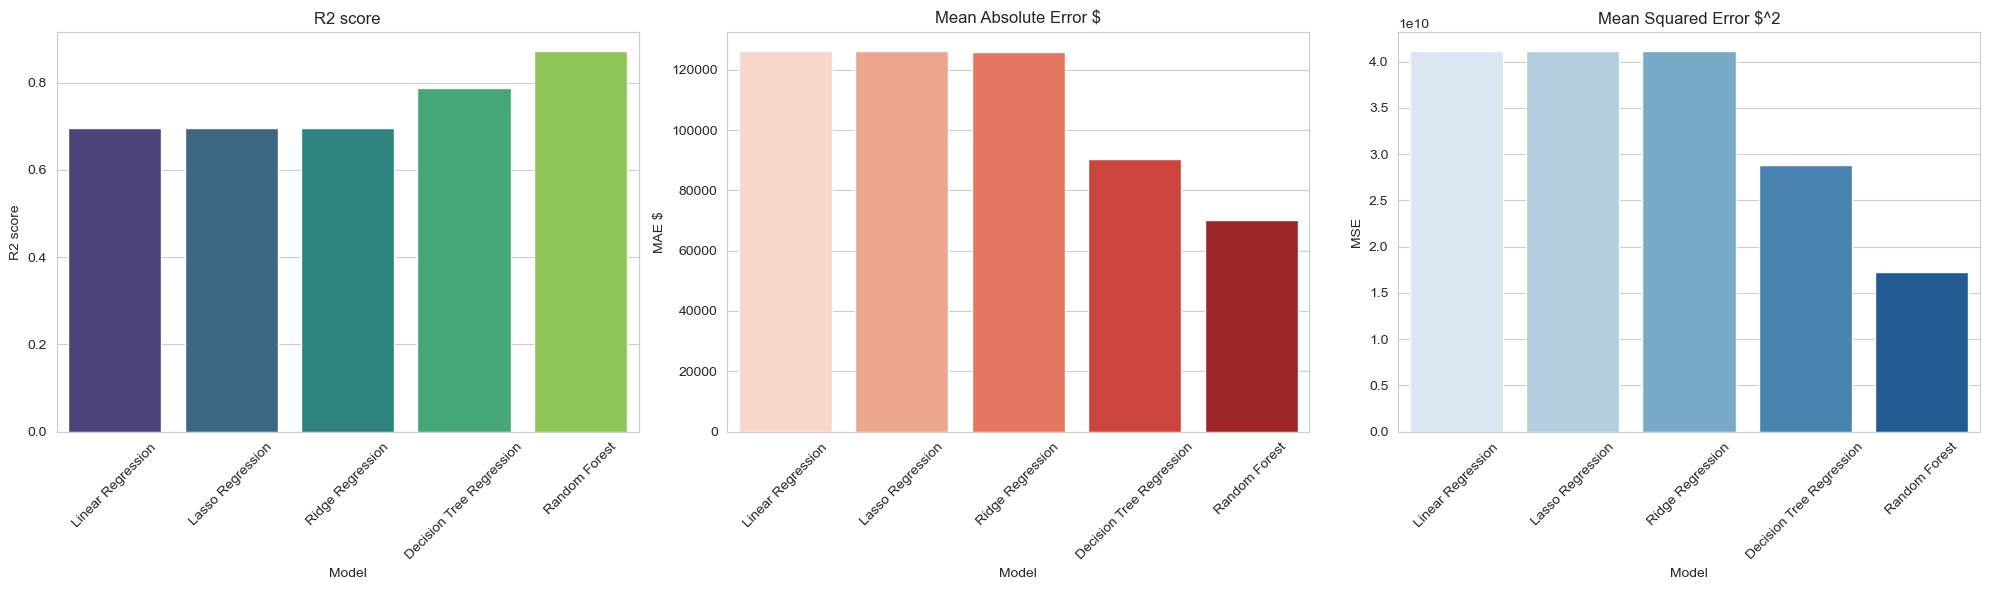

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")          # Create DataFrame

plt.figure(figsize=(20,6))


plt.subplot(1,3,1)                  # Plot for R2 score (higher is better)
sns.barplot(x="Model",
            y="R2",
            data=df_results,
            palette='viridis',
            hue='Model',
            legend=False)
plt.title('R2 score')
plt.ylabel('R2 score')
plt.xticks(rotation=45)



plt.subplot(1,3,2)                    # Plot for MAE (lower is better)
sns.barplot(x="Model",
            y="MAE",
            data=df_results,
            palette='Reds',
            hue='Model',
            legend=False)
plt.title('Mean Absolute Error $')
plt.ylabel('MAE $')
plt.xticks(rotation=45)

plt.subplot(1,3,3)                   # Plot for the MSE (lower is better)
sns.barplot(x="Model",
            y="MSE",
            data=df_results,
            palette='Blues',
            hue='Model',
            legend=False)
plt.title('Mean Squared Error $^2')
plt.ylabel('MSE')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Task 4: Normalization

Apply min-max normalization to the data and repeat all the experiments **by using the same hyper-parameters for the models**. Again, report the values of Mean Squared Error, Mean Absolute Error, and R2 score.

Compare the performance of the models and discuss your conclusions. How do the models compare when they operate on standardized and non-standardized data?

In [16]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
from tqdm import tqdm

# ----------------------- Min-Max Normalization ------------------------ #
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha = 100),
    "Lasso Regression": Lasso(alpha = 100,max_iter=10000, tol=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth = 10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
}

results_min_max = []

print("Running Task 4 (Min-Max Normalization)...")

for name, model in models.items():

    print(f"Running model: {name}")                         # We print each model everytime it runs

    model_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', model)
    ])

    mse_list = []
    mae_list = []
    r2_list = []

    for state in tqdm([0, 1, 42],
                      desc=f"CV States for {name}",          # We set a Loading bar
                      leave=False,
                      colour='green'):

        kf = KFold(n_splits=5,
                   shuffle=True,
                   random_state=state)

        scorers = {
            'MSE': make_scorer(mean_squared_error),
            'MAE': make_scorer(mean_absolute_error),
            'R2': make_scorer(r2_score)
        }

        cv_results = cross_validate(model_pipeline,
                                    X,
                                    y,
                                    cv=kf,
                                    scoring=scorers)


        mse_list.append(np.mean(cv_results['test_MSE']))
        mae_list.append(np.mean(cv_results['test_MAE']))
        r2_list.append(np.mean(cv_results['test_R2']))

    #
    results_min_max.append([                                  # Store the grand means across 5 folds
        name,
        np.mean(mse_list),
        np.mean(mae_list),
        np.mean(r2_list),
    ])

df_min_max = pd.DataFrame(results_min_max, columns=['Model', 'MSE', 'MAE', 'R2'])

display(df_min_max)

Running Task 4 (Min-Max Normalization)...
Running model: Linear Regression


Running model: Ridge Regression


Running model: Lasso Regression


Running model: Decision Tree


Running model: Random Forest


,Model,MSE,MAE,R2
0,Linear Regression,4.115640e+10,126264.104799,0.695262
1,Ridge Regression,4.499909e+10,122571.567070,0.667955
2,Lasso Regression,4.124099e+10,126619.119721,0.694593
3,Decision Tree,2.878866e+10,90430.835681,0.786904
4,Random Forest,1.702050e+10,69671.830136,0.874187


**Comparison & Conclusion**

We compared the performance of our models using two different scaling techniques: Standardization and Min Max Normalization.

* Performance summary:
1. Linear Regression model: R2 score did not change at all
2. Ridge Regression model: R2 score became slightly worse (0.695 -> 0.668)
3. Lasso Regression model: R2 score slightly dropped (0.6953 -> 0.6945)
4. Decision Tree : R2 score remained the same (0.787)
5. Random Forest : Negligible inrease of R2 score (0.873 -> 0.874)

* Key observations:

Thee based models are invariant to scaling. The Decision Tree and Random Forest models performed exactly the same regardless of the scaling method . This is expected because tree algorithms rely on sorting the data to find the split thresholds.Min Max scaling preserve the order of the data so the tree makes the exact same splits.

The Ordinary Linear Regression model found the same predictive hyperplane in both cases. The model adjusted its coefficients to match the new scale of the features resulting in identical predictions.

Ridge Regression model turned to be the most sensitive one (R2 decreased). This happened due to the min max scaler's sensitivity to outliers. If a feature has a one massive outlier, Min Max squashes the majority of the data into a tiny range. This distorts the distance between points making it harder for the L2 regularization to find the optimal penalty.

Lasso Regression also showed a slight performance drop . This probably occurred because Lasso includes a penalty term based on the magnitude of the coefficients. Changing the feature scale (from standard to minmax) the size of the features changes and the model tries to adjust the coefficients by increasing them, but at the same time the penalty term punishes larger coefficients. This conflict between minimizing the error and satisfying the regularization penalty leads to worse performance of the model and its predictability.

* Conclusion:

Standardization with standard scaler turned to be the preferred method for this dataset, particularly for the linear models. However for our best performing model (Random Forest) the choice of scaling was irrelevant.





# Task 5: Dimensionality Reduction

In this task you will study the effect of dimensionality reduction in the performance of our regression models. More specifically, you will create a **new target space with 10 dimensions** by applying Principle Component Analysis (PCA) **on the standardized data**.

Discuss the results.


In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
from tqdm import tqdm

# ----------------------- PCA Dimensionality Reduction ------------------------ #
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha = 100),
    "Lasso Regression": Lasso(alpha = 100,max_iter=10000, tol=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth = 10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
}

results_pca = []

print("Running Task 5 (PCA Dimensionality Reduction)...")

for name, model in models.items():

    print(f"Running model: {name}")

    model_pipeline = Pipeline([                                 # Standardization is required for PCA
    ('scaler', StandardScaler()),
    ('PCA', PCA(n_components=10)),
    ('regressor', model)
    ])

    mse_list = []
    mae_list = []
    r2_list = []

    for state in tqdm([0, 1, 42],
                      desc=f"PCA CV States: {name}",
                      leave=False,
                      colour='green'):

        kf = KFold(n_splits=5,
                   shuffle=True,
                   random_state=state)

        scorers = {
            'MSE': make_scorer(mean_squared_error),
            'MAE': make_scorer(mean_absolute_error),
            'R2': make_scorer(r2_score)
        }

        cv_results = cross_validate(model_pipeline,
                                    X,
                                    y,
                                    cv=kf,
                                    scoring=scorers)


        mse_list.append(np.mean(cv_results['test_MSE']))         # Store the mean values across 3 random states
        mae_list.append(np.mean(cv_results['test_MAE']))
        r2_list.append(np.mean(cv_results['test_R2']))

    results_pca.append([                                         # Store the grand means across 5 folds
        name,
        np.mean(mse_list),
        np.mean(mae_list),
        np.mean(r2_list),
    ])

df_pca = pd.DataFrame(results_pca, columns=['Model', 'MSE', 'MAE', 'R2'])
df_pca


Running Task 5 (PCA Dimensionality Reduction)...
Running model: Linear Regression


Running model: Ridge Regression


Running model: Lasso Regression


Running model: Decision Tree


Running model: Random Forest


,Model,MSE,MAE,R2
0,Linear Regression,4.591163e+10,133462.191903,0.660048
1,Ridge Regression,4.591179e+10,133356.185726,0.660060
2,Lasso Regression,4.591191e+10,133440.080191,0.660048
3,Decision Tree,4.617238e+10,115577.476284,0.655953
4,Random Forest,2.819731e+10,90491.643043,0.790377


**Discussion and Results-Task 5 (PCA)**
In this experiment, we applied principal component analysis (PCA) to reduce the dataset to 10 dimensions before training. Comparing the results with the standard experiment (Task 3) we can observe:

* Linear Regression model : R2 score decreased from 0.695 -> 0.66
* Ridge Regression (L2) : R2 score decreased from 0.695 -> 0.66
* Lasso Regression (L1) model : R2 score decreased from 0.695 -> 0.66
* Decision Tree model : R2 score decreased from 0.79 -> 0.65
* Random Forest model : R2 score decreased from 0.87 -> 0.79

**Specifically:**

The drop in R2 score across all models indicates that the top 10 principal components can not capture the 100% of the variance in the house prices. The rest components we discarded probably contained crucial information for accurate predictions.

The decision tree had the biggest performance loss falling below the linear models. The reason this happened may be the PCA's rotation of axes. The features now are abstract combinations of the original features, so decision trees struggle to find meanignful split points (thresholds) on these vectors, losing their ability to isolate non linear patterns effectively.

Interestingly, Linear, Ridge and Lasso regressions converged to the exact same score (0.66). The reason behind this may be the linearly independent features created by PCA.

Random Forest remained the best performing model.
